In [1]:
# Set up Python Facilities
import matplotlib.pyplot as plt
import numpy as np
import scipy
from scipy.optimize import curve_fit
from scipy import stats
from scipy.stats import poisson
from scipy.stats import norm
import math
import pandas as pd
%matplotlib inline

In [2]:
#Identifying and reading the data
df = pd.read_csv("part1data.csv")
df = df.iloc[1:]
df = df.sort_values(by='Voltage', ascending=False)
df

,Resistance Uncertainty,Resistance,Digits of resistance,Voltage,Voltage Uncertainty
3,998.4000,99800.0,3,9.540,0.067700
1,11960.0000,996000.0,3,9.520,0.067600
2,21940.0000,1994000.0,4,9.520,0.067600
4,99.8400,9980.0,3,9.490,0.067450
8,68.7200,6090.0,3,9.470,0.067350
7,60.7200,5090.0,3,9.450,0.067250
6,17.9360,1992.0,4,9.360,0.066800
10,12.6160,1327.0,4,9.320,0.066600
5,9.9840,998.0,3,9.270,0.066350
12,6.3840,548.0,3,9.180,0.065900


In [3]:
voltage = df["Voltage"]
dvoltage = df["Voltage Uncertainty"]

resistance = df["Resistance"]
dresistance = df["Resistance Uncertainty"]

# v = IR
# I = R 
current = voltage / resistance

dcurrent = np.sqrt( (dvoltage * (1/resistance) ) ** 2 + (dresistance * ( - voltage) * (1 / (resistance ** 2))) ** 2)

y_var =  current
y_uncertainty = dcurrent

x_var = voltage
x_uncertainty = dvoltage

In [4]:
np.sqrt( (dvoltage * (1/resistance) ) ** 2 + (dresistance * ( - voltage) * (1 / (resistance ** 2))) ** 2)

3     1.172462e-06
1     1.333416e-07
2     6.252142e-08
4     1.166925e-05
8     2.074114e-05
7     2.578916e-05
6     5.398618e-05
10    8.353085e-05
5     1.142570e-04
12    2.292290e-04
9     4.368910e-04
11    7.584079e-04
19    6.887712e-04
14    8.688808e-04
13    1.054598e-03
21    1.537073e-03
20    1.814999e-03
15    2.210041e-03
17    2.834633e-03
18    3.951049e-03
16    6.291836e-03
28    8.628553e-03
22    1.513194e-02
29    2.051936e-02
23    3.567352e-02
24    5.475647e-02
25    7.707155e-02
26    1.658393e-01
27    2.459832e-01
dtype: float64

In [5]:
# for x, y in zip(x_var, y_var):
#     print(x, ",", y)

In [6]:
#Preparing the Plots
x_label = "Voltage (Volts)"
y_label = "Current (Amperes)"
title = "Current (I) to Voltage (V) of Resistor Over 9V Battery"
xmax = max(x_var) * 1.05
xmin = 0 # min(x_var) - (xmax * 0.05)

ymin = min(y_var) * 0.95
ymax = max(y_var) * 1.05

Now lets make a graph of y_var vs. x_var, with error bars on the y data.

Text(0.5, 1.0, 'Current (I) to Voltage (V) of Resistor Over 9V Battery')

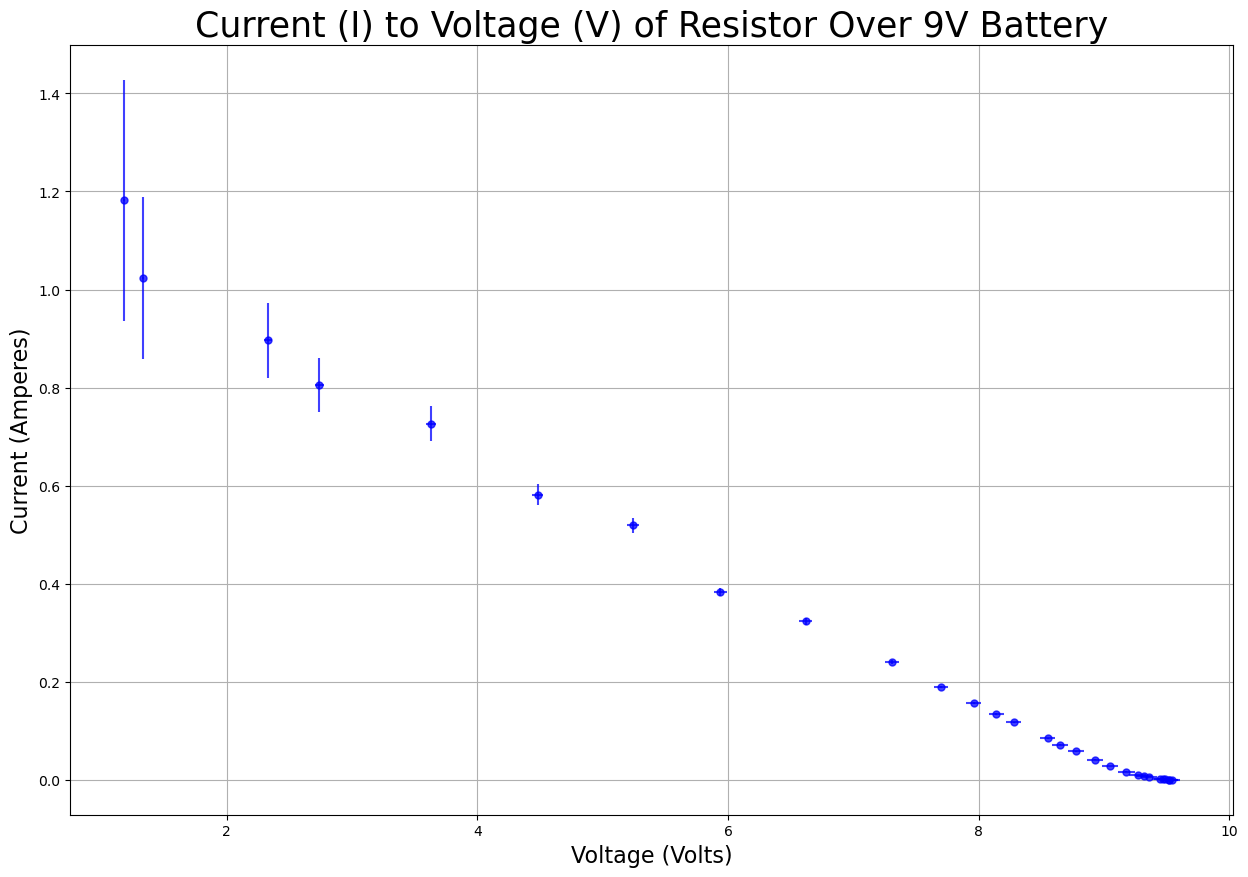

In [7]:
plt.errorbar(x_var, y_var, yerr=y_uncertainty, xerr=x_uncertainty, fmt="o", ms=5, color="blue", alpha=0.75)

plt.gcf().set_size_inches(15, 10)  # This sets the size of the plot
plt.grid(True)  # This toggles whether gridlines are displayed
plt.xlabel(x_label, fontsize=16)  # x-axis label
plt.ylabel(y_label, fontsize=16)  # y-axis label
plt.title(title, fontsize=25)  # Plot title

# To manually change the axis limits, uncomment (remove the # at the start) these lines:
#plt.ylim(ymin, ymax)  # This sets the range of the y-axis
#plt.xlim(xmin, xmax)  # This sets the range of the x-axis

# To save the plot as a .png, uncomment this:
#plt.savefig("plot", bbox_inches="tight", dpi=300)  # Saves the figure

In [8]:
def FitFunction(x, m, b):
    y = m * x + b
    return y

n_parameters = 2

In [9]:
#Parameter Bounds ([lower bounds,...],[Upper bounds,...])
param_bounds=([-np.inf,-np.inf],[np.inf,np.inf])  
initial_param=(1,1)  

In [10]:
# cut = 15
# optimized_parameters, covariance_matrix = curve_fit(FitFunction, x_var[cut:],y_var[cut:],
#                                                     sigma=y_uncertainty[cut:],absolute_sigma=True,
#                                                     bounds=param_bounds,p0=initial_param)
# parameter_errors = np.sqrt(np.diag(covariance_matrix))

In [11]:
from scipy.odr import * 

In [12]:
mydata = RealData(x_var, y_var, sx=x_uncertainty, sy=y_uncertainty)

def f(B, x):
    '''Linear function y = m*x + b'''
    # B is a vector of the parameters.
    # x is an array of the current x values.
    # x is in the same format as the x passed to Data or RealData.
    #
    # Return an array in the same format as y passed to Data or RealData.
    return B[0]*x + B[1]

linear = Model(f)

myodr = ODR(mydata, linear, beta0=[1., 2.])

myoutput = myodr.run()

myoutput.pprint()

Beta: [-0.11524358  1.08089695]
Beta Std Error: [0.00223887 0.01943498]
Beta Covariance: [[ 2.52769612e-06 -2.17907012e-05]
 [-2.17907012e-05  1.90474291e-04]]
Residual Variance: 1.9830412216099276
Inverse Condition #: 0.01227252393242185
Reason(s) for Halting:
  Sum of squares convergence


In [13]:
optimized_parameters = myoutput.beta
parameter_errors = myoutput.sd_beta
# parameter_errors = np.sqrt(np.diag(myoutput.cov_beta))

## Plotting the fit results:

In [14]:
for i in range(len(optimized_parameters)):
    print(f'Parameter #{i+1}: {optimized_parameters[i]:.6e} ± {parameter_errors[i]:.1e}')

Parameter #1: -1.152436e-01 ± 2.2e-03
Parameter #2: 1.080897e+00 ± 1.9e-02


In [15]:
# First calculate a reasonable range of x values for our line
x_length = max(x_var) - min(x_var)
x_min_l = min(x_var) - 0.05*x_length
x_max_l = max(x_var) + 0.05*x_length
# Create our array of 200 linearly-spaced points
xForLine = np.linspace(x_min_l,x_max_l,200)
# Calculate the y values of the best fit line
yForLine = FitFunction(xForLine,*optimized_parameters)

In [16]:
residual = y_var - FitFunction(x_var,*optimized_parameters)

In [17]:
ndof = len(x_var) - len(optimized_parameters) - 1 # Number of degrees of freedom ndof = no. entries - no. parameters -1
ru = residual / y_uncertainty
chisq = np.sum(np.power(ru, 2)) / ndof
print("Chisq", str.format("{0:.4f}", chisq))  # Print 4 significant figures

Chisq 3170457191.1117


Now we are ready to plot the fit function with our data. We repeat the code to plot the previous graph, and then plot our fit function.

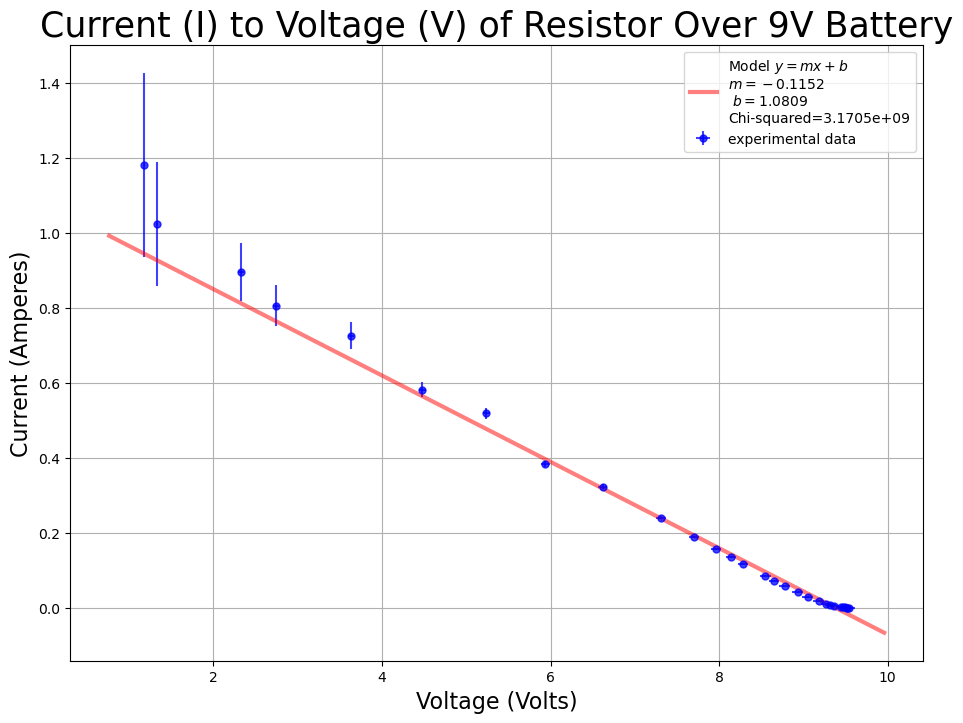

In [18]:
# Plot our data
plt.errorbar(x_var, y_var, yerr=y_uncertainty, xerr=x_uncertainty, fmt="o", ms=5, color="blue", alpha=0.75, label="experimental data")

# Add grid lines, titles, and axis labels.
plt.gcf().set_size_inches(11, 8)  # This sets the size of the plot
plt.grid(True)  # This toggles whether gridlines are displayed
plt.xlabel(x_label, fontsize=16)  # x-axis label
plt.ylabel(y_label, fontsize=16)  # y-axis label
plt.title(title, fontsize=25)  # Plot title

# To manually change the axis limits, uncomment (remove the # at the start) these lines:
#plt.ylim(ymin, ymax)  # This sets the range of the y-axis
#plt.xlim(xmin, xmax)  # This sets the range of the x-axis

# Add the line to the plot
plt.plot(xForLine, yForLine, lw=3, color="red", alpha=0.5, 
         label=f'Model $y = mx + b$ \n$m={optimized_parameters[0]:.4f}$ \n $b={optimized_parameters[1]:.4f}$\nChi-squared={chisq:.4e}')

# Add a legend
plt.legend()

# To save the plot as a .png, uncomment this:
# plt.savefig("plot_fit", bbox_inches="tight", dpi=300)  # Saves the figure
plt.savefig("figures/current_to_voltage.svg", bbox_inches="tight")  # Saves the figure

plt.show()

(0.0, 10.017)

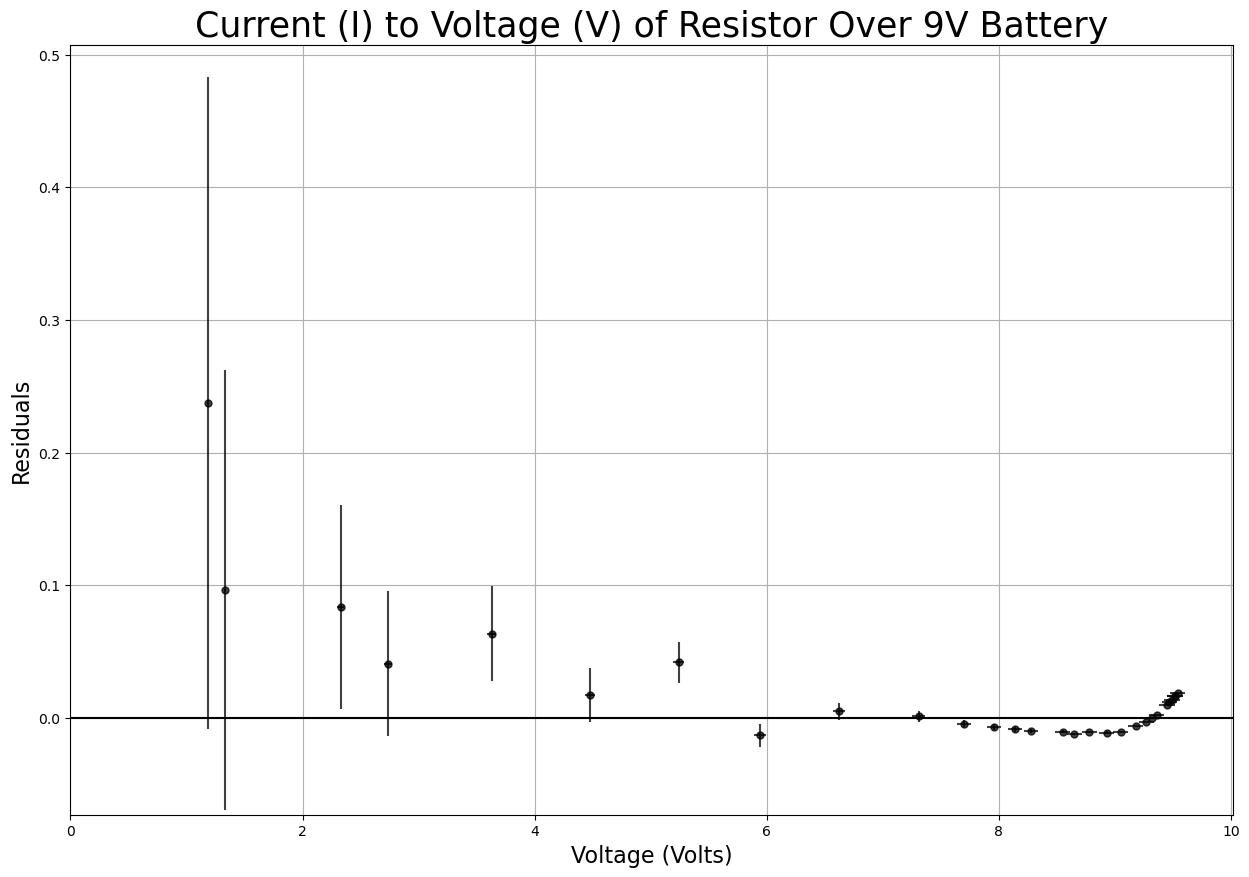

In [19]:
# Plot the residuals
plt.errorbar(x_var, residual, yerr=y_uncertainty, xerr=x_uncertainty, fmt="o", ms=5, color="black", alpha=0.75)

# Add grid lines, titles, and axis labels.
plt.gcf().set_size_inches(15, 10)  # This sets the size of the plot
plt.grid(True)  # This toggles whether gridlines are displayed
plt.xlabel(x_label, fontsize=16)  # x-axis label
plt.ylabel("Residuals", fontsize=16)  # y-axis label
plt.title(title, fontsize=25)  # Plot title

plt.axhline(0, color="black")


# Set the axis limits for the residuals plot
ymin_r= min(residual - y_uncertainty) * 1.05
ymax_r= max(residual + y_uncertainty) * 1.05
plt.ylim(ymin_r, ymax_r)  # This sets the range of the y-axis
plt.xlim(xmin, xmax)  # This sets the range of the x-axis

# To save the plot as a .png, uncomment this:
#plt.savefig("plot_residuals", bbox_inches="tight", dpi=300)  # Saves the figure

Lets also calculate the $\chi^2$ value for our fit. This indicates the goodness-of-fit:
- $\chi^2>>1$ indicates the model is not a good fit to the data, or uncertainties are likely underestimated.
- $\chi^2\sim1$ indicates the model is a good fit to the data.
- $\chi^2<<1$ indicates the model is "too good" a fit, i.e. the uncertainties are likely overestimated.

In [20]:
m = optimized_parameters[0]
dm = parameter_errors[0]
print(f"Internal Resistance = {-1/m:.4f} ± {(dm)* (1/(m**2) ) :.4f}")

Internal Resistance = 8.6773 ± 0.1686


In [21]:
# ndof = len(x_var[cut:]) - len(optimized_parameters) - 1 # Number of degrees of freedom ndof = no. entries - no. parameters -1
# ru = residual[cut:] / y_uncertainty[cut:]
# chisq = np.sum(np.power(ru, 2)) / ndof
# print("Corrected Chisq", str.format("{0:.4f}", chisq))  # Print 4 significant figures

# This time cutting the data

In [22]:
x_var

3     9.540
1     9.520
2     9.520
4     9.490
8     9.470
7     9.450
6     9.360
10    9.320
5     9.270
12    9.180
9     9.050
11    8.930
19    8.780
14    8.650
13    8.550
21    8.280
20    8.140
15    7.960
17    7.700
18    7.310
16    6.620
28    5.940
22    5.240
29    4.480
23    3.630
24    2.740
25    2.330
26    1.331
27    1.182
Name: Voltage, dtype: float64

In [23]:
cut = 13
print(x_var[cut])

cut_x_var = x_var[:cut]
cut_y_var = y_var[:cut]
cut_x_uncertainty = x_uncertainty[:cut]
cut_y_uncertainty= y_uncertainty[:cut]

x_var = x_var[cut:]
y_var = y_var[cut:]
x_uncertainty = x_uncertainty[cut:]
y_uncertainty= y_uncertainty[cut:]



8.55


In [24]:
len(x_var)

16

In [25]:
mydata = RealData(x_var, y_var, sx=x_uncertainty, sy=y_uncertainty)

def f(B, x):
    '''Linear function y = m*x + b'''
    # B is a vector of the parameters.
    # x is an array of the current x values.
    # x is in the same format as the x passed to Data or RealData.
    #
    # Return an array in the same format as y passed to Data or RealData.
    return B[0]*x + B[1]

linear = Model(f)

myodr = ODR(mydata, linear, beta0=[1., 2.])

myoutput = myodr.run()

myoutput.pprint()

Beta: [-0.12393116  1.14305499]
Beta Std Error: [0.00210218 0.01622854]
Beta Covariance: [[ 6.57091982e-06 -5.02704515e-05]
 [-5.02704515e-05  3.91603221e-04]]
Residual Variance: 0.6725317879117146
Inverse Condition #: 0.015593842525243224
Reason(s) for Halting:
  Sum of squares convergence


In [26]:
optimized_parameters = myoutput.beta
parameter_errors = myoutput.sd_beta

## Plotting the fit results:

In [27]:
for i in range(len(optimized_parameters)):
    print(f'Parameter #{i+1}: {optimized_parameters[i]:.6e} ± {parameter_errors[i]:.1e}')

Parameter #1: -1.239312e-01 ± 2.1e-03
Parameter #2: 1.143055e+00 ± 1.6e-02


In [28]:
m = optimized_parameters[0]
dm = parameter_errors[0]
print(f"Internal Resistance = {-1/m:.4f} ± {(dm)* (1/(m**2) ) :.4f}")

Internal Resistance = 8.0690 ± 0.1369


In [29]:
# First calculate a reasonable range of x values for our line
x_length = max(x_var) - min(x_var)
x_min_l = min(x_var) - 0.05*x_length
x_max_l = max(x_var) + 0.05*x_length
# Create our array of 200 linearly-spaced points
xForLine = np.linspace(x_min_l,x_max_l,200)
# Calculate the y values of the best fit line
yForLine = FitFunction(xForLine,*optimized_parameters)

Now we are ready to plot the fit function with our data. We repeat the code to plot the previous graph, and then plot our fit function.

In [30]:
residual = y_var - FitFunction(x_var,*optimized_parameters)
cut_residual = cut_y_var - FitFunction(cut_x_var,*optimized_parameters)

Lets also calculate the $\chi^2$ value for our fit. This indicates the goodness-of-fit:
- $\chi^2>>1$ indicates the model is not a good fit to the data, or uncertainties are likely underestimated.
- $\chi^2\sim1$ indicates the model is a good fit to the data.
- $\chi^2<<1$ indicates the model is "too good" a fit, i.e. the uncertainties are likely overestimated.

In [31]:
ndof = len(x_var) - len(optimized_parameters) - 1 # Number of degrees of freedom ndof = no. entries - no. parameters -1
ru = residual / y_uncertainty
chisq = np.sum(np.power(ru, 2)) / ndof
print("Chisq", str.format("{0:.4f}", chisq))  # Print 4 significant figures

Chisq 1.2024


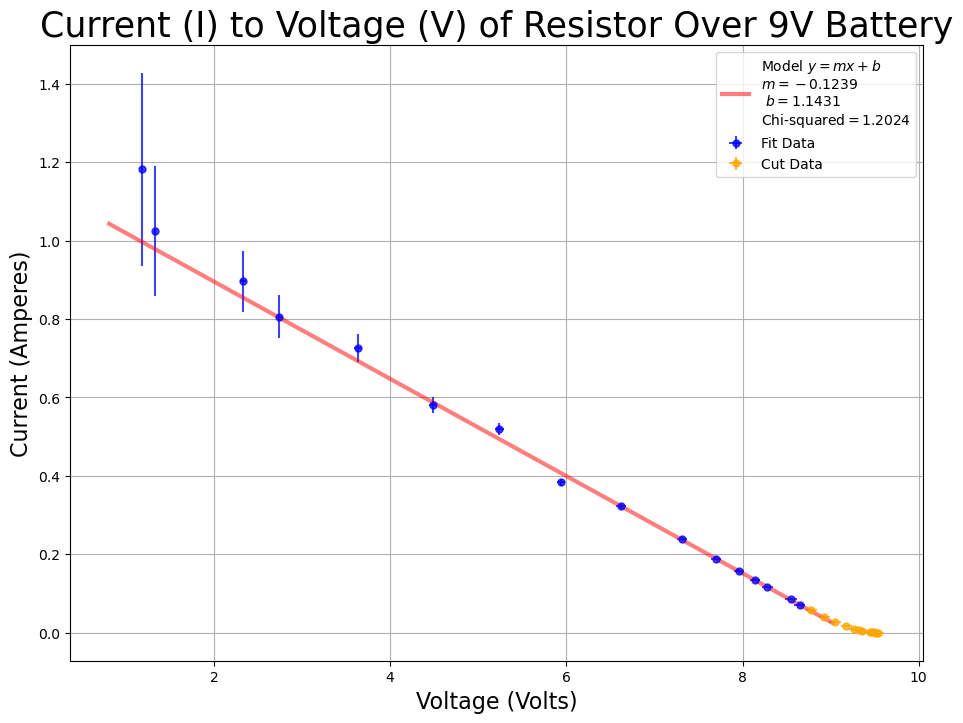

In [32]:
# Plot our data
plt.errorbar(x_var, y_var, yerr=y_uncertainty, xerr=x_uncertainty, fmt="o", ms=5, color="blue", alpha=0.75, label="Fit Data")

plt.errorbar(cut_x_var, cut_y_var, yerr=cut_y_uncertainty, xerr=cut_x_uncertainty, fmt="o", ms=5, color="orange", alpha=0.75, label="Cut Data")


# Add grid lines, titles, and axis labels.
plt.gcf().set_size_inches(11, 8)  # This sets the size of the plot
plt.grid(True)  # This toggles whether gridlines are displayed
plt.xlabel(x_label, fontsize=16)  # x-axis label
plt.ylabel(y_label, fontsize=16)  # y-axis label
plt.title(title, fontsize=25)  # Plot title

# To manually change the axis limits, uncomment (remove the # at the start) these lines:
#plt.ylim(ymin, ymax)  # This sets the range of the y-axis
#plt.xlim(xmin, xmax)  # This sets the range of the x-axis

# Add the line to the plot
plt.plot(xForLine, yForLine, lw=3, color="red", alpha=0.5, 
         label=f'Model $y = mx + b$ \n$m={optimized_parameters[0]:.4f}$ \n $b={optimized_parameters[1]:.4f}$\nChi-squared$={chisq:.4f}$')

# Add a legend
plt.legend()

# To save the plot as a .png, uncomment this:
# plt.savefig("plot_fit", bbox_inches="tight", dpi=300)  # Saves the figure
plt.savefig("figures/current_to_voltage_cut.svg", bbox_inches="tight")  # Saves the figure

plt.show()

(0.0, 10.017)

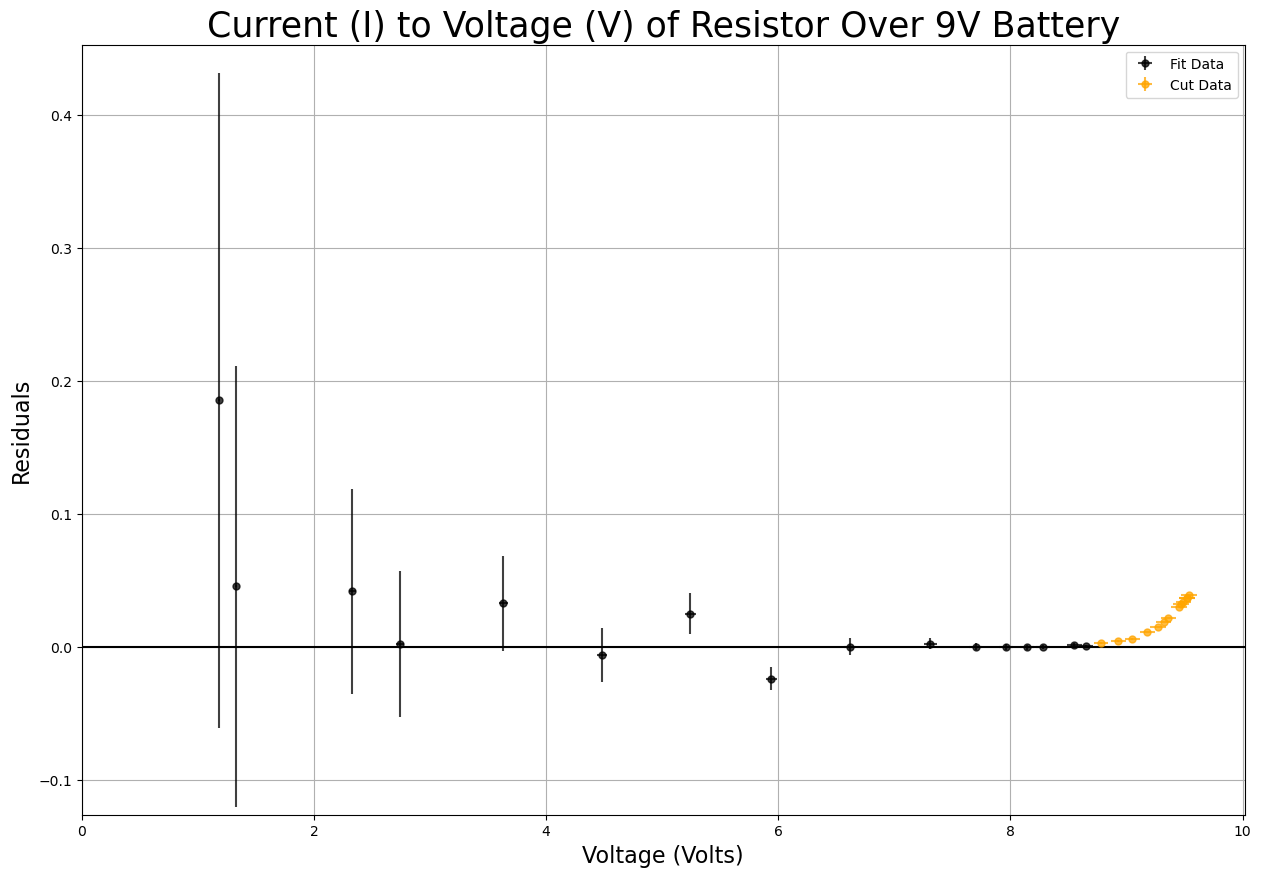

In [33]:
# Plot the residuals
plt.errorbar(x_var, residual, yerr=y_uncertainty, xerr=x_uncertainty, fmt="o", ms=5, color="black", alpha=0.75, label="Fit Data")

plt.errorbar(cut_x_var, cut_residual, yerr=cut_y_uncertainty, xerr=cut_x_uncertainty, fmt="o", ms=5, color="orange", alpha=0.75, label="Cut Data")

# Add grid lines, titles, and axis labels.
plt.gcf().set_size_inches(15, 10)  # This sets the size of the plot
plt.grid(True)  # This toggles whether gridlines are displayed
plt.xlabel(x_label, fontsize=16)  # x-axis label
plt.ylabel("Residuals", fontsize=16)  # y-axis label
plt.title(title, fontsize=25)  # Plot title

plt.axhline(0, color="black")

# Add a legend
plt.legend()

# Set the axis limits for the residuals plot
ymin_r= min(residual - y_uncertainty) * 1.05
ymax_r= max(residual + y_uncertainty) * 1.05
plt.ylim(ymin_r, ymax_r)  # This sets the range of the y-axis
plt.xlim(xmin, xmax)  # This sets the range of the x-axis

# To save the plot as a .png, uncomment this:
#plt.savefig("plot_residuals", bbox_inches="tight", dpi=300)  # Saves the figure

In [34]:
len(x_var) + cut 

29

In [35]:
df.iloc[cut - 1]

Resistance Uncertainty      1.4064
Resistance                150.8000
Digits of resistance        4.0000
Voltage                     8.7800
Voltage Uncertainty         0.0639
Name: 19, dtype: float64

In [36]:
cut_x_var

3     9.54
1     9.52
2     9.52
4     9.49
8     9.47
7     9.45
6     9.36
10    9.32
5     9.27
12    9.18
9     9.05
11    8.93
19    8.78
Name: Voltage, dtype: float64